<a href="https://colab.research.google.com/github/Bhargava-007/Machine-Learning-2-1/blob/main/Exp_2_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving titanic.csv to titanic.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")


In [ ]:
df = pd.read_csv("titanic.csv")

In [ ]:
print("First 5 rows of the dataset:")
display(df.head())



First 5 rows of the dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())




Shape of dataset (rows, columns): (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-

In [ ]:
num_cols = ['age', 'fare', 'sibsp', 'parch']

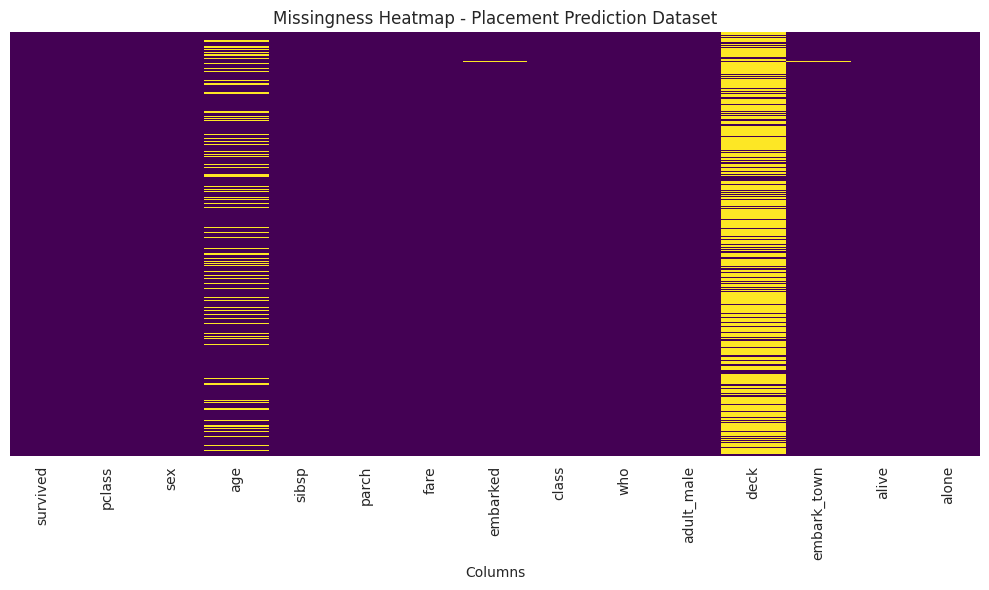

In [ ]:
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


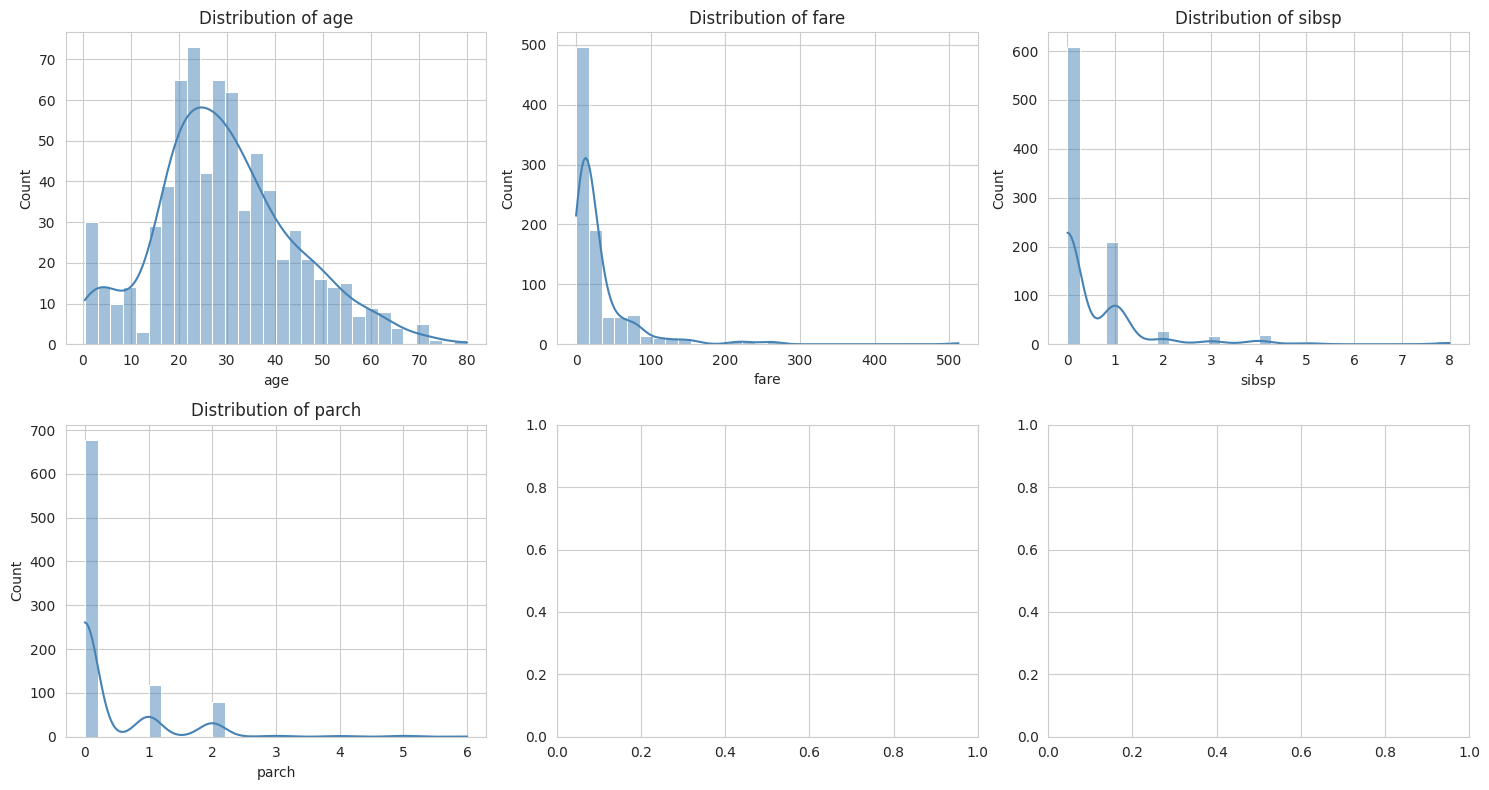

In [ ]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


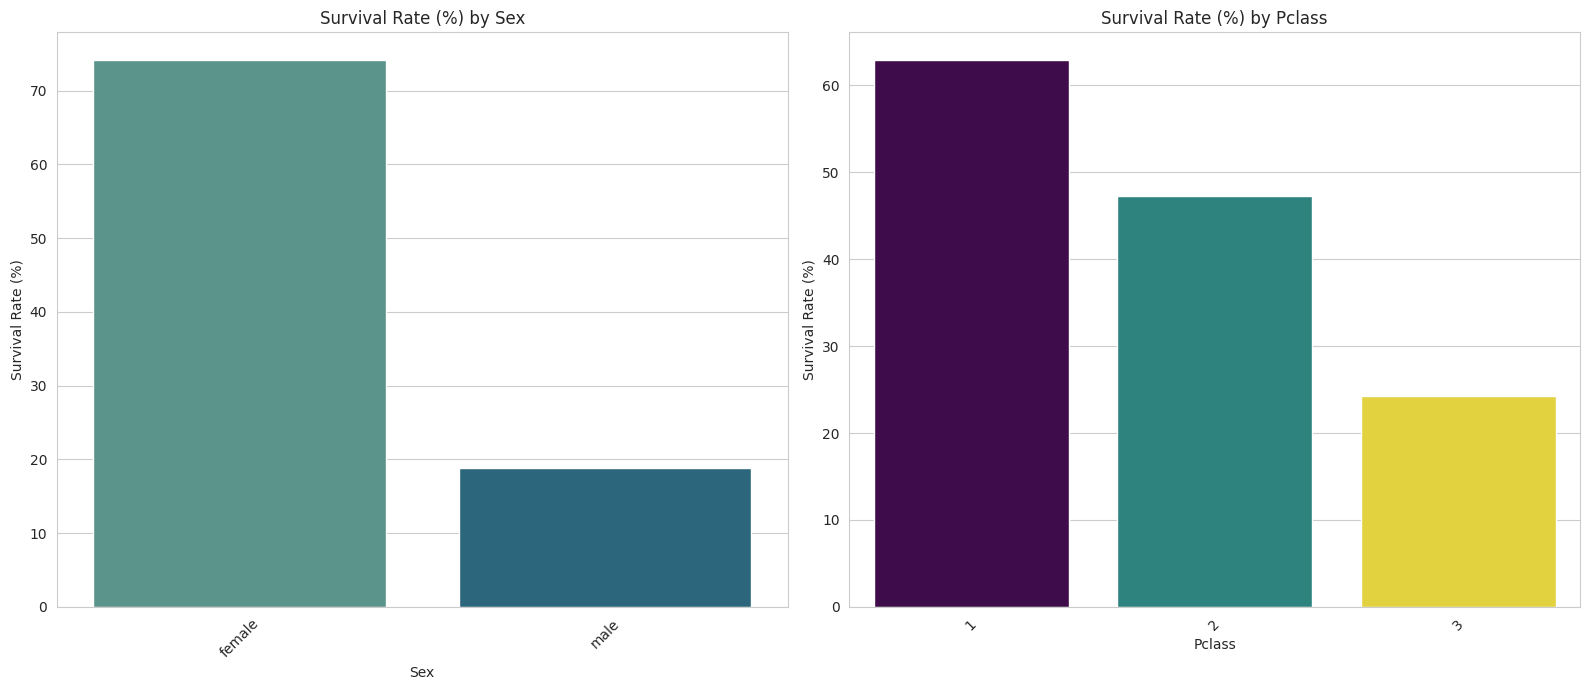


Survival rate (%) by Sex:
sex
female    74.20
male      18.89
Name: survived, dtype: float64

Survival rate (%) by Pclass:
pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


In [ ]:
fig3, axes = plt.subplots(1, 2, figsize=(16, 7))


survival_rate_sex = df.groupby('sex')['survived'].mean().sort_values(ascending=False) * 100
sns.barplot(x=survival_rate_sex.index, y=survival_rate_sex.values, hue=survival_rate_sex.index, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Survival Rate (%) by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].tick_params(axis='x', rotation=45)


survival_rate_pclass = df.groupby('pclass')['survived'].mean().sort_values(ascending=False) * 100
sns.barplot(x=survival_rate_pclass.index, y=survival_rate_pclass.values, hue=survival_rate_pclass.index, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Survival Rate (%) by Pclass')
axes[1].set_xlabel('Pclass')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSurvival rate (%) by Sex:")
print(survival_rate_sex.round(2))
print("\nSurvival rate (%) by Pclass:")
print(survival_rate_pclass.round(2))

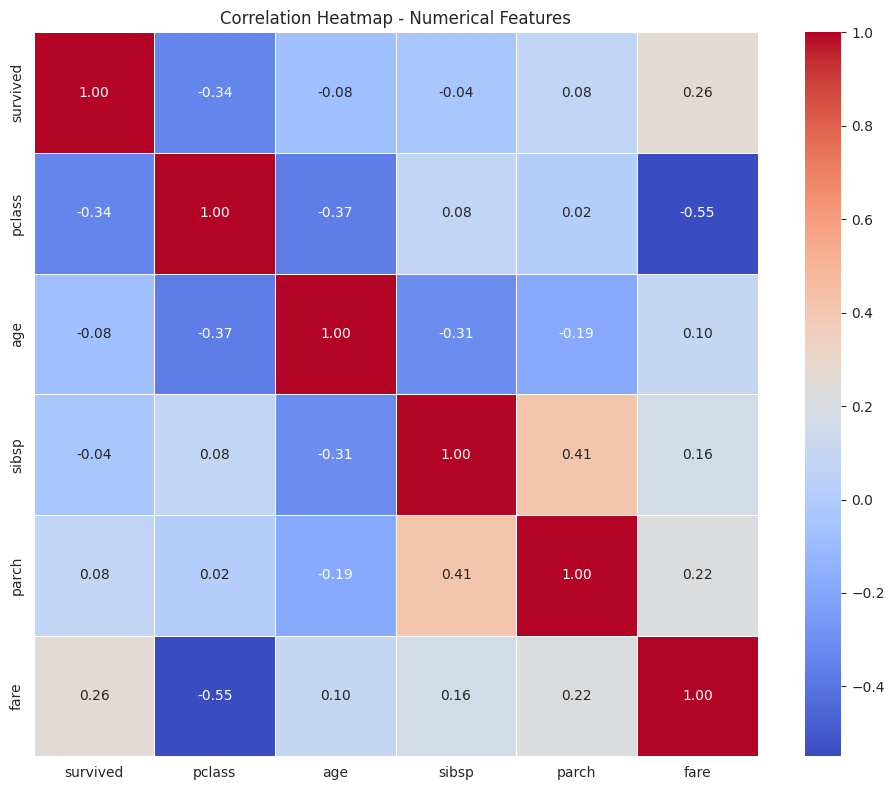

In [ ]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()




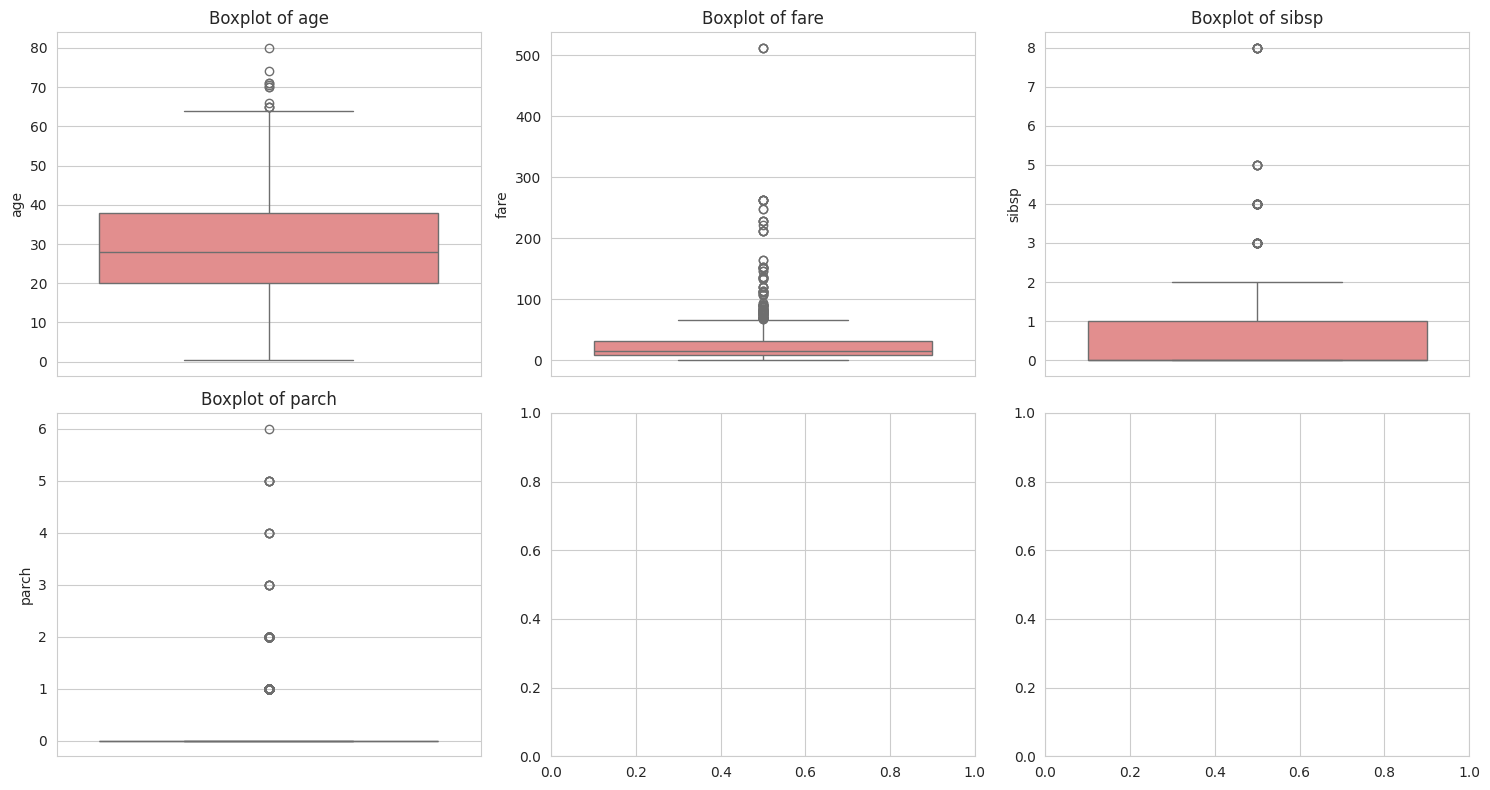

In [ ]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [ ]:
pdf = PdfPages('EDA_Report_Titanic.pdf')

pdf.savefig(fig1)
pdf.savefig(fig2)
pdf.savefig(fig3)
pdf.savefig(fig4)
pdf.savefig(fig5)

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")




EDA_Report.pdf created successfully with 5 pages!


In [ ]:
files.download('EDA_Report_Titanic.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>